In [7]:
# -*- coding:utf-8 -*-
"""
walk_map_minfirst_loop_nopid_with_marker.py
- Open-loop ทั้งหมด (ไม่ใช้ PID)
- ลูป: (0) คาลิเบรตทิศ z↔yaw -> (1) ปรับ yaw -> (2) Reactive -> (3) หน่วง -> (4) DFS 1 step -> (5) ปรับ yaw -> (6) วน
- ตั้ง BEST_YAW / BEST_ROLL จากค่าจริงตอนเริ่มรัน "ครั้งเดียว"
- รวม vision marker: บันทึก mark_N/E/S/W เฉพาะเมื่อ wall_N/E/S/W == True เท่านั้น
- เพิ่มการเก็บเส้นทางและสถานะการพบ marker ลงไฟล์ path_log.csv (ไม่กระทบการเคลื่อนที่)
"""

import time
import csv
import math
import statistics
import os  # <<< ใช้สำหรับเช็ค/สร้างไฟล์ log
from typing import Dict, Tuple, Optional, List
from robomaster import robot

# ===================== CONFIG (ทั่วไป) =====================
CONN_TYPE = "ap"
FREQ_HZ = 10
SCAN_SETTLE_S = 0.10
READ_TIMEOUT = 1.0
GIMBAL_SPEED = 300
REACTIVE_SETTLE_S = 0.08
LOOP_SLEEP = 0.05

# ============ CONFIG (Attitude/Yaw Hold) ============
BEST_YAW: Optional[float] = None
BEST_ROLL: Optional[float] = None
YAW_TOL = 1.5
ROTATE_SPEED = 30
WAIT_AFTER_ROTATE = 0.4
BASELINE_SAMPLES = 20
BASELINE_TIMEOUT_S = 3.0

# ===================== CONFIG (Reactive L/F/R/B) =====================
TOO_CLOSE = 0.15
TOO_FAR_LO, TOO_FAR_HI = 0.20, 0.30
CLEAR_ALL = 0.40
QUIET_BAND_LO, QUIET_BAND_HI = 0.16, 0.19

STEP_M = 0.10
XY_SPEED = 0.5

ANGLES_LFRB = {"ซ้าย": -90, "หน้า": 0, "ขวา": 90, "หลัง": 180}

# ===================== CONFIG (DFS) =====================
CELL_SIZE = 0.6
X_SPEED_DEFAULT = 0.35
TOF_THRESHOLD_MM = 600
TOF_MAX_VALID_MM = 3000
TOF_STALE_TIMEOUT = 1.0
CSV_FILENAME = "map_data.csv"

DIRECTIONS = {
    "N": (0.0,   0, +1,   0.0),
    "E": (90.0, +1,  0,  90.0),
    "S": (180.0, 0, -1, 180.0),
    "W": (-90.0,-1,  0, -90.0),
}

# ===================== STATE =====================
map_data: Dict[Tuple[int, int], Dict] = {}
pos = (0, 0)
stack: List[Tuple[int,int,str]] = []

pose_x = 0.0
pose_y = 0.0
pose_yaw = 0.0

last_tof_mm: Optional[float] = None
last_tof_time: float = 0.0
last_gimbal_yaw: Optional[float] = None

current_yaw = 0.0
current_roll = 0.0
_z_to_yaw_sign = 1

# ---- MARKER STATE ----
marker_last_list: List[object] = []
marker_last_time = 0.0
MARKER_STALE_S = 0.6

# ===================== CONFIG (PID ใช้เฉพาะตอนวิ่งด้วย X_SPEED_DEFAULT) =====================
DFS_CTRL_HZ = 40
DFS_CTRL_DT = 1.0 / DFS_CTRL_HZ
DFS_PID_VEL_MAX = 0.8          # เพดานความเร็วที่ PID สั่ง (m/s)

PID_KP = 1.25
PID_KI = 0.1
PID_KD = 0.3
PID_I_MIN, PID_I_MAX = -0.35, 0.35
PID_D_ALPHA = 0.2              # 0..1 (มาก=กรองน้อย)

# ถ้าใส่ PID แล้วระยะเดินเกิน/ขาด เพราะ odom ไม่ใช่เมตร -> คูณสเกลนี้
# เริ่มที่ 1.0 ถ้าตรงแล้ว; ถ้าเดินไกล ~5 เท่า ให้ตั้ง 5.0 แล้วค่อยคาลิเบรต
ODOM_TO_M = 1.0

# ===================== CONFIG (Path logging) =====================
PATH_LOG = "path_log.csv"
MARKER_FAR_M = 0.35  # เกณฑ์ "ไกล" เพื่อจด candidate (เมตร)

# ==================================PID Class==================================
class PID:
    def __init__(self, Kp, Ki, Kd, out_min=0.0, out_max=1.0, i_min=-0.5, i_max=0.5, deriv_alpha=0.2):
        self.Kp, self.Ki, self.Kd = Kp, Ki, Kd
        self.out_min, self.out_max = out_min, out_max
        self.i_min, self.i_max = i_min, i_max
        self.deriv_alpha = deriv_alpha
        self.integral = 0.0
        self.prev_e = 0.0
        self.prev_deriv = 0.0
        self.first = True

    def step(self, setpoint, measured, dt):
        e = setpoint - measured
        # D-term (กรอง)
        raw_d = 0.0 if self.first else (e - self.prev_e) / dt
        d = self.deriv_alpha * raw_d + (1 - self.deriv_alpha) * self.prev_deriv
        # anti-windup แบบง่าย: บวก I ถ้าไม่ชนเพดาน
        u_no_i = self.Kp * e + self.Kd * d
        if not ((u_no_i >= self.out_max and e > 0) or (u_no_i <= self.out_min and e < 0)):
            self.integral = max(self.i_min, min(self.i_max, self.integral + e * dt))
        u = u_no_i + self.Ki * self.integral
        u = max(self.out_min, min(self.out_max, u))
        self.prev_e, self.prev_deriv, self.first = e, d, False
        return u

# ==================================PID Move==================================    
def move_slide_pid(chassis, dist, direction_deg, set_speed):
    """
    เดินระยะ dist (m) ตามทิศ direction_deg โดยใช้ PID รักษาความเร็ว = set_speed (m/s)
    ระยะ/สปีดคำนวณจาก odom แล้วคูณ ODOM_TO_M ให้เป็นเมตรจริง
    """
    if dist <= 0 or set_speed <= 0:
        return

    ux = math.cos(math.radians(direction_deg))
    uy = math.sin(math.radians(direction_deg))

    pid = PID(PID_KP, PID_KI, PID_KD,
              out_min=0.0, out_max=DFS_PID_VEL_MAX,
              i_min=PID_I_MIN, i_max=PID_I_MAX,
              deriv_alpha=PID_D_ALPHA)

    prev_x, prev_y = pose_x, pose_y
    progressed = 0.0
    next_t = time.time()
    t_start = next_t

    # time-guard กันค้าง (เผื่อ 25% จากเวลาที่ควรใช้)
    safety_timeout = 1.25 * dist / max(0.05, set_speed)

    while True:
        now = time.time()
        if now < next_t:
            time.sleep(max(0.0, next_t - now))
        next_t += DFS_CTRL_DT

        cur_x, cur_y = pose_x, pose_y
        dx, dy = cur_x - prev_x, cur_y - prev_y
        ds_along_m = (dx * ux + dy * uy) * ODOM_TO_M          # ระยะจริงในรอบนี้ (m)
        measured_speed = max(0.0, ds_along_m / DFS_CTRL_DT)   # m/s

        corr = pid.step(set_speed, measured_speed, DFS_CTRL_DT)
        v_cmd = max(0.0, min(DFS_PID_VEL_MAX, corr + set_speed))  # feed-forward setpoint + PID

        chassis.drive_speed(v_cmd * ux, v_cmd * uy, 0.0)

        progressed += max(0.0, ds_along_m)
        prev_x, prev_y = cur_x, cur_y

        if progressed >= dist:
            break
        if (time.time() - t_start) > safety_timeout:
            print(f"[DFS-PID] time-guard stop: {progressed:.2f}/{dist:.2f} m")
            break

    chassis.drive_speed(0.0, 0.0, 0.0)
    time.sleep(0.05)

# ===================== PATH LOG STATE/HELPERS =====================
path_step = 0                              # P1..Pn
pending_marker = None                      # {'cell':(x,y),'dir':..,'ids':'1;2'}
last_move_for_confirm = None               # {'from':(x,y),'to':(x,y),'dir':..}

def init_path_log(reset=True):
    """สร้าง/รีเซ็ตไฟล์ path_log.csv พร้อม header"""
    mode = "w" if reset else ("a" if os.path.exists(PATH_LOG) else "w")
    with open(PATH_LOG, mode, newline="") as f:
        w = csv.writer(f)
        w.writerow(["event","step","t","from_x","from_y","to_x","to_y","dir","ids","note"])

def _write_row(event, step, fr, to, dir_name="", ids="", note=""):
    with open(PATH_LOG, "a", newline="") as f:
        w = csv.writer(f)
        fx, fy = (fr if fr else ("",""))
        tx, ty = (to if to else ("",""))
        w.writerow([event, step, f"{time.time():.3f}", fx, fy, tx, ty, dir_name, ids, note])

def log_move(fr_xy, to_xy, dir_name):
    global path_step
    path_step += 1
    _write_row("move", path_step, fr_xy, to_xy, dir_name, "", "")

def log_marker_candidate(cell_xy, dir_name, ids, dist_m):
    _write_row("marker_candidate", "", cell_xy, "", dir_name, ids, f"far~{dist_m:.2f}m")

def log_marker_confirm(cell_xy, dir_name, ids):
    _write_row("marker_confirm", "", cell_xy, "", dir_name, ids, "confirmed after step")

def log_marker_still_visible(cell_xy, dir_name, ids):
    _write_row("marker_still_visible", "", cell_xy, "", dir_name, ids, "still visible after step")

# ===================== SUBSCRIBE CALLBACKS =====================
def sub_position_handler(info):
    global pose_x, pose_y, pose_yaw
    try:
        if isinstance(info, (list, tuple)):
            pose_x, pose_y = float(info[0]), float(info[1])
            if len(info) > 2:
                pose_yaw = float(info[2])
        elif isinstance(info, dict):
            pose_x = float(info.get("x", pose_x))
            pose_y = float(info.get("y", pose_y))
            pose_yaw = float(info.get("yaw", info.get("theta", pose_yaw)))
    except Exception:
        pass

def sub_attitude_handler(attitude_info):
    global current_yaw, current_roll
    try:
        yaw, pitch, roll = attitude_info
        current_yaw = float(yaw)
        current_roll = float(roll)
    except Exception:
        pass

def tof_handler(info):
    global last_tof_mm, last_tof_time
    try:
        val = info[0] if isinstance(info, (list, tuple)) else (info.get("distance") if isinstance(info, dict) else info)
        if val is not None and 0 < val < TOF_MAX_VALID_MM:
            last_tof_mm = float(val)
            last_tof_time = time.time()
        else:
            last_tof_mm = None
    except Exception:
        last_tof_mm = None

def on_detect_marker(marker_info):
    """รับ list ของ (x, y, w, h, info) -> เก็บเฉพาะ info"""
    global marker_last_list, marker_last_time
    marker_last_list = []
    try:
        if marker_info:
            for i in range(len(marker_info)):
                x, y, w, h, info = marker_info[i]
                marker_last_list.append(info)
        marker_last_time = time.time()
    except Exception:
        marker_last_list = []
        marker_last_time = 0.0

def get_recent_markers() -> List[object]:
    if (time.time() - marker_last_time) <= MARKER_STALE_S:
        return list(marker_last_list)
    return []

# ===================== UTILS =====================
def mm_to_m(mm: Optional[float]) -> float:
    return float('nan') if mm is None else mm / 1000.0

def ang_norm180(a):
    return ((a + 180.0) % 360.0) - 180.0

def shortest_delta(target, current):
    return ang_norm180(target - current)

def calibrate_sign(chassis) -> int:
    print("[CAL] เริ่มคาลิเบรตทิศทาง z ...")
    y0 = current_yaw
    cmd = 10.0
    chassis.move(x=0, y=0, z=cmd, z_speed=ROTATE_SPEED).wait_for_completed()
    time.sleep(WAIT_AFTER_ROTATE)
    y1 = current_yaw
    actual = shortest_delta(y1, y0)
    sign = 1 if actual > 0 else -1
    print(f"[CAL] yaw0={y0:.2f}° -> yaw1={y1:.2f}° | actual Δ={actual:.2f}° => sign={sign:+d}")
    chassis.move(x=0, y=0, z=-cmd, z_speed=ROTATE_SPEED).wait_for_completed()
    time.sleep(WAIT_AFTER_ROTATE)
    print("[CAL] คืนตำแหน่งเรียบร้อย")
    return sign

def correct_yaw_if_needed(chassis, label="pre-loop"):
    if BEST_YAW is None:
        print(f"[ATT] ({label}) baseline ยังไม่พร้อม ข้ามการปรับ yaw")
        return False
    err = shortest_delta(BEST_YAW, current_yaw)
    if abs(err) <= YAW_TOL:
        print(f"[ATT] ({label}) ok: yaw={current_yaw:.2f}° ~ {BEST_YAW:.2f}° (|Δ|={abs(err):.2f}° ≤ {YAW_TOL}°)")
        return False
    z_cmd = err * _z_to_yaw_sign
    print(f"[ATT] ({label}) correct: curr={current_yaw:.2f}° -> target={BEST_YAW:.2f}° | err={err:.2f}° | send z={z_cmd:.2f}°")
    chassis.move(x=0, y=0, z=z_cmd, z_speed=ROTATE_SPEED).wait_for_completed()
    time.sleep(WAIT_AFTER_ROTATE)
    print(f"[ATT] ({label}) final yaw={current_yaw:.2f}°")
    if BEST_ROLL is not None and abs(current_roll - BEST_ROLL) > 3.0:
        print(f"[WARN] roll เพี้ยน: now {current_roll:.2f}° vs base {BEST_ROLL:.2f}°")
    return True

def set_cell(x, y):
    if (x, y) not in map_data:
        map_data[(x, y)] = {
            "walls": dict.fromkeys("NESW", False),
            "marks": dict.fromkeys("NESW", None),  # mark ต่อทิศ
            "visited": False
        }

def save_map():
    try:
        with open(CSV_FILENAME, "w", newline="") as f:
            w = csv.writer(f)
            w.writerow([
                "ID","x","y",
                "wall_N","wall_E","wall_S","wall_W",
                "visited",
                "mark_N","mark_E","mark_S","mark_W",
                "pose_x","pose_y","pose_yaw"
            ])
            rid = 1
            for (x, y), cell in sorted(map_data.items()):
                walls = cell["walls"]; marks = cell["marks"]
                def mval(k):
                    v = marks.get(k)
                    return "FALSE" if (v is None or v == "") else v
                w.writerow([
                    rid, x, y,
                    walls["N"], walls["E"], walls["S"], walls["W"],
                    cell["visited"],
                    mval("N"), mval("E"), mval("S"), mval("W"),
                    pose_x, pose_y, pose_yaw
                ])
                rid += 1
        print(f"[INFO] Map saved to {CSV_FILENAME}")
    except Exception as e:
        print(f"[ERROR] Failed to save map: {e}")

# ===================== MOTION =====================
def move_slide(chassis, dist, direction_deg, speed=XY_SPEED):
    if dist == 0 or speed == 0:
        return
    duration = abs(dist / speed)
    x_speed = speed * math.cos(math.radians(direction_deg))
    y_speed = speed * math.sin(math.radians(direction_deg))
    start = time.time()
    while time.time() - start < duration:
        chassis.drive_speed(x_speed, y_speed, 0.0)
        time.sleep(0.05)
    chassis.drive_speed(0.0, 0.0, 0.0)
    time.sleep(0.05)

SLIDE_LEFT_DEG   = -90.0
SLIDE_RIGHT_DEG  =  90.0
SLIDE_FORWARD_DEG=   0.0
SLIDE_BACK_DEG   = 180.0

# ===================== GIMBAL / SCAN =====================
def gimbal_to(ep_gimbal, yaw):
    global last_gimbal_yaw
    try:
        if last_gimbal_yaw is None or abs(last_gimbal_yaw - yaw) > 1.0:
            ep_gimbal.moveto(pitch=0, yaw=yaw, yaw_speed=GIMBAL_SPEED).wait_for_completed()
            last_gimbal_yaw = yaw
        time.sleep(SCAN_SETTLE_S)
    except Exception:
        try:
            ep_gimbal.moveto(pitch=0, yaw=yaw)
        except Exception:
            pass
        last_gimbal_yaw = yaw
        time.sleep(SCAN_SETTLE_S + 0.02)

def scan_lfrb_once(ep_gimbal) -> Dict[str, float]:
    out: Dict[str, float] = {}
    for name, yaw in ANGLES_LFRB.items():
        gimbal_to(ep_gimbal, yaw)
        start = time.time()
        got = None
        while time.time() - start < READ_TIMEOUT:
            if last_tof_mm is not None and (time.time() - last_tof_time) < TOF_STALE_TIMEOUT:
                got = last_tof_mm
                break
            time.sleep(0.01)
        out[name] = mm_to_m(got)
    return out

def print_scan_lfrb(res: Dict[str, float]):
    def fmt(v): return ("---" if (v != v) else f"{v:.3f}")
    print(f"ซ้าย {fmt(res['ซ้าย'])} หน้า {fmt(res['หน้า'])} ขวา {fmt(res['ขวา'])} หลัง {fmt(res['หลัง'])}")

# ===================== Reactive DECISION (Open-loop) =====================
def decide_and_act_with_priority(ep_chassis, ep_gimbal, d: Dict[str, float]) -> bool:
    def is_between(v, lo, hi): return (v == v) and (lo <= v <= hi)
    def is_lt(v, th):         return (v == v) and (v < th)

    vals = [v for v in d.values() if v == v]
    if len(vals) == 4:
        if all(QUIET_BAND_LO <= v <= QUIET_BAND_HI for v in vals):
            print("[Reactive] none (ทุกทิศ 0.16–0.19 m)")
            return False
        if all(v >= CLEAR_ALL for v in vals):
            print("[Reactive] none (เคลียร์ทุกทิศ >= 0.4 m)")
            return False

    actions = []

    safe_d = {k: (d[k] if d[k] == d[k] else 999.0) for k in d}
    dir_min = min(safe_d, key=lambda k: safe_d[k])
    vmin = safe_d[dir_min]
    print(f"[Min-first] ต่ำสุด: {dir_min} = {vmin:.3f} m")

    def plan_side(which, dist):
        if which == "ซ้าย":
            if dist < TOO_CLOSE:
                actions.append(("ซ้ายใกล้", SLIDE_RIGHT_DEG, STEP_M, "[OpenLoop] ซ้ายใกล้ -> สไลด์ขวา"))
            elif is_between(dist, TOO_FAR_LO, TOO_FAR_HI):
                actions.append(("ซ้ายไกล", SLIDE_LEFT_DEG, STEP_M, "[OpenLoop] ซ้ายไกล -> สไลด์ซ้าย"))
        elif which == "ขวา":
            if dist < TOO_CLOSE:
                actions.append(("ขวาใกล้", SLIDE_LEFT_DEG, STEP_M, "[OpenLoop] ขวาใกล้ -> สไลด์ซ้าย"))
            elif is_between(dist, TOO_FAR_LO, TOO_FAR_HI):
                actions.append(("ขวาไกล", SLIDE_RIGHT_DEG, STEP_M, "[OpenLoop] ขวาไกล -> สไลด์ขวา"))

    if dir_min in ("ซ้าย", "ขวา"):
        plan_side(dir_min, vmin)
    elif dir_min == "หน้า":
        if vmin < TOO_CLOSE:
            actions.append(("หน้าใกล้", SLIDE_BACK_DEG, STEP_M, "[OpenLoop] หน้าใกล้ -> ถอย"))
    elif dir_min == "หลัง":
        if vmin < TOO_CLOSE:
            actions.append(("หลังใกล้", SLIDE_FORWARD_DEG, STEP_M, "[OpenLoop] หลังใกล้ -> เดินหน้า"))
        elif is_between(vmin, TOO_FAR_LO, TOO_FAR_HI):
            actions.append(("หลังไกล", SLIDE_BACK_DEG, STEP_M, "[OpenLoop] หลังไกล -> ถอย"))

    if is_lt(d.get("ซ้าย", float('nan')), TOO_CLOSE):
        plan_side("ซ้าย", d["ซ้าย"])
    if is_lt(d.get("ขวา", float('nan')), TOO_CLOSE):
        plan_side("ขวา", d["ขวา"])
    if is_between(d.get("ซ้าย", float('nan')), TOO_FAR_LO, TOO_FAR_HI):
        plan_side("ซ้าย", d["ซ้าย"])
    if is_between(d.get("ขวา", float('nan')), TOO_FAR_LO, TOO_FAR_HI):
        plan_side("ขวา", d["ขวา"])
    if is_lt(d.get("หน้า", float('nan')), TOO_CLOSE):
        actions.append(("หน้าใกล้", SLIDE_BACK_DEG, STEP_M, "[OpenLoop] หน้าใกล้ -> ถอย"))
    if is_lt(d.get("หลัง", float('nan')), TOO_CLOSE):
        actions.append(("หลังใกล้", SLIDE_FORWARD_DEG, STEP_M, "[OpenLoop] หลังใกล้ -> เดินหน้า"))
    if is_between(d.get("หลัง", float('nan')), TOO_FAR_LO, TOO_FAR_HI):
        actions.append(("หลังไกล", SLIDE_BACK_DEG, STEP_M, "[OpenLoop] หลังไกล -> ถอย"))

    seen, deduped = set(), []
    for name, deg, dist, msg in actions:
        if name not in seen:
            seen.add(name)
            deduped.append((name, deg, dist, msg))

    if not deduped:
        print("[Reactive] none (ไม่เข้าเงื่อนไข)")
        return False

    for name, deg, dist, msg in deduped:
        print(msg + f" | step={dist:.2f} m @ {deg:.0f}°")
        move_slide(ep_chassis, dist=dist, direction_deg=deg, speed=XY_SPEED)
        time.sleep(0.02)

    return True

# ===================== DFS SCAN / UPDATE WALLS & MARKS =====================
def set_cell_walls_from_scan(ep_gimbal, x, y):
    global pending_marker, last_move_for_confirm
    set_cell(x, y)
    cell = map_data[(x, y)]
    walls = cell["walls"]
    marks = cell["marks"]

    seen_any_ids_this_cell = set()  # สำหรับตรวจยืนยัน marker หลังขยับ

    for dir_name, (gimbal_yaw, dx, dy, _) in DIRECTIONS.items():
        gimbal_to(ep_gimbal, gimbal_yaw)
        time.sleep(0.02)

        dist = last_tof_mm if (time.time() - last_tof_time) < TOF_STALE_TIMEOUT else None

        # เดิม: อัปเดตกำแพง
        if dist is None:
            walls[dir_name] = True
            print(f"[SCAN] ({x},{y}) {dir_name}: --- -> WALL")
        else:
            walls[dir_name] = (dist < TOF_THRESHOLD_MM)
            print(f"[SCAN] ({x},{y}) {dir_name}: {dist:.0f} mm -> {'WALL' if walls[dir_name] else 'OPEN'}")

        # เดิม: เก็บ mark เฉพาะเมื่อเป็นกำแพง
        if walls[dir_name]:
            recent_ids = get_recent_markers()
            if recent_ids:
                marks[dir_name] = ";".join(str(i) for i in recent_ids)
                print(f"[MARK] ({x},{y}) {dir_name}: FOUND -> {marks[dir_name]}")
            else:
                if marks[dir_name] is None:
                    marks[dir_name] = None
                print(f"[MARK] ({x},{y}) {dir_name}: none")
        else:
            marks[dir_name] = None  # ไม่ใช่กำแพง -> ไม่เก็บ mark

        # เพิ่ม: รวบรวม marker ที่เห็นใน cell นี้
        recent_ids = get_recent_markers()
        for mid in recent_ids:
            try:
                seen_any_ids_this_cell.add(str(mid))
            except:
                pass

        # เพิ่ม: ถ้า OPEN และเห็น marker ไกล -> จดเป็น candidate
        if (not walls[dir_name]) and recent_ids and (dist is not None):
            dist_m = mm_to_m(dist)
            if dist_m == dist_m and dist_m >= MARKER_FAR_M:
                ids_str = ";".join(str(i) for i in recent_ids)
                pending_marker = {"cell": (x, y), "dir": dir_name, "ids": ids_str}
                log_marker_candidate((x, y), dir_name, ids_str, dist_m)

    # เพิ่ม: หากเพิ่งขยับเข้าหา candidate ให้ตรวจยืนยัน
    if last_move_for_confirm and pending_marker:
        if last_move_for_confirm.get("from") == pending_marker.get("cell") and \
           last_move_for_confirm.get("dir")  == pending_marker.get("dir"):
            ids_set = set((pending_marker.get("ids") or "").split(";"))
            if ids_set and ids_set.isdisjoint(seen_any_ids_this_cell):
                log_marker_confirm(pending_marker["cell"], pending_marker["dir"], pending_marker["ids"])
            else:
                log_marker_still_visible(pending_marker["cell"], pending_marker["dir"], pending_marker["ids"])
            pending_marker = None
            last_move_for_confirm = None

def dfs_one_step(ep_chassis, ep_gimbal) -> bool:
    global pos, stack, last_move_for_confirm
    x, y = pos
    set_cell(x, y)
    map_data[(x, y)]["visited"] = True

    set_cell_walls_from_scan(ep_gimbal, x, y)

    # เงื่อนไขเปิดใช้ PID เฉพาะกรณีที่ตั้งไว้ (ไม่เปลี่ยนพฤติกรรมเดิมของคุณ)
    use_pid = math.isclose(X_SPEED_DEFAULT, 0.5, rel_tol=0.02, abs_tol=1e-9)

    moved = False
    for dir_name, (_, dx, dy, heading_deg) in DIRECTIONS.items():
        nx, ny = x + dx, y + dy
        set_cell(nx, ny)
        if not map_data[(x, y)]["walls"][dir_name] and not map_data[(nx, ny)]["visited"]:
            print(f"[DFS] {pos} -> {(nx, ny)} via {dir_name}")

            # เพิ่ม: บันทึกเส้นทาง (P1..Pn)
            log_move((x, y), (nx, ny), dir_name)
            # ถ้ามี candidate ที่ cell นี้และทิศเดียวกัน ให้เตรียมเช็คหลังขยับ
            if pending_marker and pending_marker.get("dir") == dir_name and pending_marker.get("cell") == (x, y):
                last_move_for_confirm = {"from": (x, y), "to": (nx, ny), "dir": dir_name}
            else:
                last_move_for_confirm = None

            # การเคลื่อนที่เดิม (ไม่แตะ)
            if use_pid:
                move_slide_pid(ep_chassis, CELL_SIZE, direction_deg=heading_deg, set_speed=X_SPEED_DEFAULT)
            else:
                move_slide(ep_chassis, CELL_SIZE, direction_deg=heading_deg, speed=X_SPEED_DEFAULT)

            stack.append((x, y, dir_name))
            pos = (nx, ny)
            moved = True
            break

    if moved:
        return True

    if not stack:
        print("[DFS] Complete (no more moves).")
        return False

    px, py, came_dir = stack.pop()
    opp_dir = {"N":"S","S":"N","E":"W","W":"E"}[came_dir]
    opp_heading = DIRECTIONS[opp_dir][3]
    print(f"[DFS-Back] {pos} -> {(px, py)} via {opp_dir}")

    # เพิ่ม: บันทึกเส้นทางตอนถอย
    log_move(pos, (px, py), opp_dir)
    # ถ้ามี candidate ที่ cell ปัจจุบันและทิศเดียวกัน ให้เตรียมเช็คหลังขยับ
    if pending_marker and pending_marker.get("dir") == opp_dir and pending_marker.get("cell") == pos:
        last_move_for_confirm = {"from": pos, "to": (px, py), "dir": opp_dir}
    else:
        last_move_for_confirm = None

    # การเคลื่อนที่เดิม (ไม่แตะ)
    if use_pid:
        move_slide_pid(ep_chassis, CELL_SIZE, direction_deg=opp_heading, set_speed=X_SPEED_DEFAULT)
    else:
        move_slide(ep_chassis, CELL_SIZE, direction_deg=opp_heading, speed=X_SPEED_DEFAULT)
    pos = (px, py)
    return True

# ===================== BASELINE INIT =====================
def init_baseline_attitude():
    global BEST_YAW, BEST_ROLL
    yaw_samples, roll_samples = [], []
    start = time.time()
    while (len(yaw_samples) < BASELINE_SAMPLES) and (time.time() - start < BASELINE_TIMEOUT_S):
        yaw_samples.append(float(current_yaw))
        roll_samples.append(float(current_roll))
        time.sleep(0.05)
    BEST_YAW = statistics.fmean(yaw_samples) if yaw_samples else float(current_yaw)
    BEST_ROLL = statistics.fmean(roll_samples) if yaw_samples else float(current_roll)
    print(f"[BASELINE] BEST_YAW={BEST_YAW:.2f}°, BEST_ROLL={BEST_ROLL:.2f}° (samples={len(yaw_samples)})")

# ===================== MAIN LOOP =====================
def main():
    global _z_to_yaw_sign
    bot = robot.Robot()
    bot.initialize(conn_type=CONN_TYPE)

    chassis = bot.chassis
    gimbal  = bot.gimbal
    sensor  = bot.sensor
    vision  = bot.vision
    camera  = bot.camera

    chassis.sub_position(freq=10, callback=sub_position_handler)
    chassis.sub_attitude(freq=20, callback=sub_attitude_handler)
    sensor.sub_distance(freq=FREQ_HZ, callback=tof_handler)

    # เริ่มสตรีมกล้อง (เหมือนเดิม)
    try:
        camera.start_video_stream(display=True)
    except Exception:
        pass
    try:
        vision.sub_detect_info(name="marker", callback=on_detect_marker)
    except Exception:
        print("[WARN] vision marker not available")

    gimbal.moveto(pitch=0, yaw=0, yaw_speed=GIMBAL_SPEED).wait_for_completed()
    time.sleep(0.3)

    # baseline attitude (เดิม)
    init_baseline_attitude()

    # สร้างไฟล์ path_log.csv พร้อม header (เพิ่มเฉย ๆ ไม่กระทบการเคลื่อนที่)
    init_path_log(reset=True)

    print("[START] Reactive + DFS + Attitude-hold (NO PID, open-loop). Ctrl+C เพื่อหยุด")
    try:
        while True:
            _z_to_yaw_sign = calibrate_sign(chassis)
            correct_yaw_if_needed(chassis, label="pre-loop")

            dists_m = scan_lfrb_once(gimbal)
            print_scan_lfrb(dists_m)
            _ = decide_and_act_with_priority(chassis, gimbal, dists_m)

            time.sleep(REACTIVE_SETTLE_S)

            did_dfs = dfs_one_step(chassis, gimbal)
            if not did_dfs:
                print("[DONE] Exploration complete. Stop loop.")
                break

            correct_yaw_if_needed(chassis, label="post-loop")
            time.sleep(LOOP_SLEEP)

    except KeyboardInterrupt:
        print("[STOP] Interrupted by user")
    finally:
        try: vision.unsub_detect_info(name="marker")
        except Exception: pass
        try: camera.stop_video_stream()
        except Exception: pass
        try: sensor.unsub_distance()
        except Exception: pass
        try: chassis.unsub_position()
        except Exception: pass
        try: chassis.unsub_attitude()
        except Exception: pass
        try: gimbal.moveto(pitch=0, yaw=0, yaw_speed=GIMBAL_SPEED).wait_for_completed()
        except Exception: pass
        try: bot.close()
        except Exception: pass
        save_map()

if __name__ == "__main__":
    main()


[BASELINE] BEST_YAW=-96.70°, BEST_ROLL=1.16° (samples=20)
[START] Reactive + DFS + Attitude-hold (NO PID, open-loop). Ctrl+C เพื่อหยุด
[CAL] เริ่มคาลิเบรตทิศทาง z ...
[CAL] yaw0=-96.70° -> yaw1=-105.09° | actual Δ=-8.39° => sign=-1
[CAL] คืนตำแหน่งเรียบร้อย
[ATT] (pre-loop) ok: yaw=-96.33° ~ -96.70° (|Δ|=0.37° ≤ 1.5°)
ซ้าย 0.578 หน้า 1.532 ขวา 0.190 หลัง 0.340
[Min-first] ต่ำสุด: ขวา = 0.190 m
[Reactive] none (ไม่เข้าเงื่อนไข)
[SCAN] (0,0) N: 1493 mm -> OPEN
[SCAN] (0,0) E: 191 mm -> WALL
[MARK] (0,0) E: none
[SCAN] (0,0) S: 340 mm -> WALL
[MARK] (0,0) S: none
[SCAN] (0,0) W: 1447 mm -> OPEN
[DFS] (0, 0) -> (0, 1) via N
[ATT] (post-loop) ok: yaw=-96.78° ~ -96.70° (|Δ|=0.08° ≤ 1.5°)
[CAL] เริ่มคาลิเบรตทิศทาง z ...
[CAL] yaw0=-96.79° -> yaw1=-105.95° | actual Δ=-9.16° => sign=-1
[CAL] คืนตำแหน่งเรียบร้อย
[ATT] (pre-loop) ok: yaw=-97.19° ~ -96.70° (|Δ|=0.49° ≤ 1.5°)
ซ้าย 0.850 หน้า 0.876 ขวา 0.194 หลัง 1.021
[Min-first] ต่ำสุด: ขวา = 0.194 m
[Reactive] none (ไม่เข้าเงื่อนไข)
[SCAN] (0,1) 

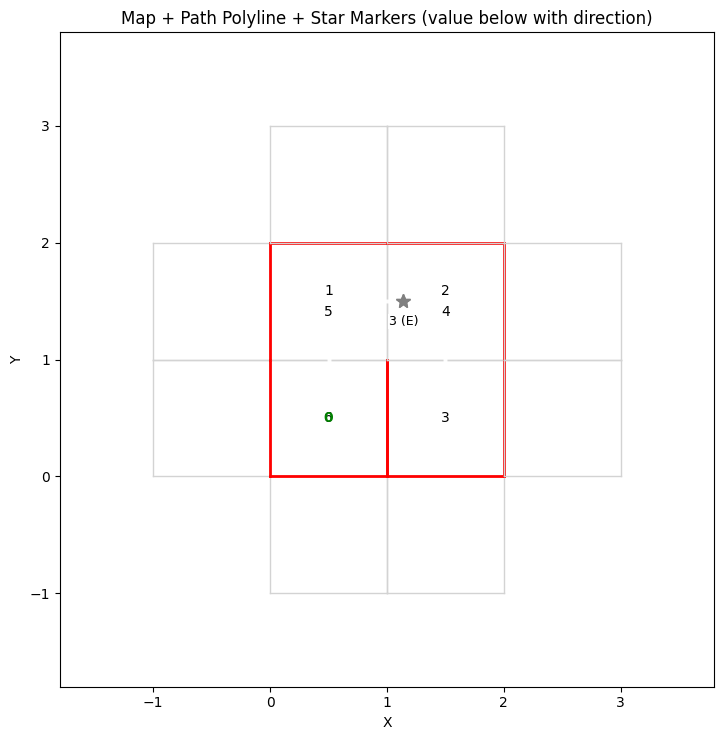

Carved walls: 0 segments removed; Skipped non-adjacent/invalid moves: 0


In [12]:
# plot_map_and_path.py
import csv
import math
import os
import re
import matplotlib.pyplot as plt
from collections import defaultdict

MAP_CSV  = "map_data.csv"
PATH_CSV = "path_log.csv"   # ถ้าไม่มีไฟล์ จะวาดแค่แมป

# ============ ปรับได้ ============
CELL_SIZE_M = 0.6   # ขนาด 1 ช่อง (เมตร)
STEP_STARTS_AT_ZERO = True   # ให้สเต็ปเริ่มที่ 0 แล้วนับเฉพาะ event=move
MARKER_OUTSET_CELLS = 0.14   # ระยะดันดาว “ออกนอกกำแพง” (หน่วยเป็นจำนวนช่อง)
# ===============================

# -------------------- helpers --------------------
def _bool(v):
    if isinstance(v, bool): return v
    s = str(v).strip().lower()
    return s in ("true","1","yes","y")

def _read_map(filename):
    """อ่าน cell + walls + markers จาก map_data.csv"""
    cells = {}
    marks = {}   # {(x,y): {"N": "1;4", ...}}
    with open(filename, newline="", encoding="utf-8") as f:
        rdr = csv.DictReader(f)
        for row in rdr:
            x = int(row["x"]); y = int(row["y"])
            walls = {
                "N": _bool(row["wall_N"]),
                "E": _bool(row["wall_E"]),
                "S": _bool(row["wall_S"]),
                "W": _bool(row["wall_W"]),
            }
            cells[(x,y)] = walls
            # marker ในไฟล์แมป (ใช้วาดด้วย)
            m = {k: (row.get(f"mark_{k}") or "").strip() for k in "NESW"}
            m = {k:(None if (v=="" or v.upper()=="FALSE") else v) for k,v in m.items()}
            marks[(x,y)] = m
    return cells, marks

def _read_path(filename):
    """อ่าน path + marker_candidate จาก path_log.csv (ทนคอลัมน์สะกดต่างกัน)"""
    if not os.path.exists(filename):
        return [], None, []

    moves = []
    candidates = []
    start_cell = None

    with open(filename, newline="", encoding="utf-8") as f:
        rdr = csv.DictReader(f)
        cols = {c.lower(): c for c in rdr.fieldnames}

        def col(*names):
            for n in names:
                k = n.lower()
                if k in cols: return cols[k]
            return None

        c_event = col("event")
        cx1 = col("from_x","x1","sx","start_x")
        cy1 = col("from_y","y1","sy","start_y")
        cx2 = col("to_x","x2","dx","dest_x","end_x")
        cy2 = col("to_y","y2","dy","dest_y","end_y")
        cdir = col("dir","direction")
        cids = col("ids")
        cnote = col("note")

        step_counter =  0

        for r in rdr:
            ev = (r.get(c_event) or "").strip().lower() if c_event else ""
            if ev == "marker_candidate":
                candidates.append({
                    "cell": ( _safe_int(r.get(cx1)), _safe_int(r.get(cy1)) ),
                    "side": (r.get(cdir) or "").strip().upper()[:1],
                    "ids":  (r.get(cids) or "").strip(),
                    "note": (r.get(cnote) or "").strip()
                })
                continue

            if ev != "move":
                continue

            fx, fy = _safe_int(r.get(cx1)), _safe_int(r.get(cy1))
            tx, ty = _safe_int(r.get(cx2)), _safe_int(r.get(cy2))
            if fx is None or fy is None or tx is None or ty is None:
                continue
            if (fx,fy) == (tx,ty):
                continue  # ไม่ถือว่า move

            step_counter += 1
            if start_cell is None:
                start_cell = (fx,fy)

            moves.append({
                "step": step_counter,
                "from": (fx,fy),
                "to":   (tx,ty),
                "dir":  (r.get(cdir) or "")
            })

    return moves, start_cell, candidates

def _safe_int(v):
    if v is None or v == "": return None
    try:
        return int(float(v))
    except Exception:
        return None

def _cell_center(x,y): return x+0.5, y+0.5

# ====== ฟังก์ชันเกี่ยวกับทิศ/กำแพง/ตำแหน่งบนกำแพง ======
def _direction(a, b):
    """คืนทิศ N/E/S/W ตาม delta ระหว่าง cell a->b (ต้องเป็นเพื่อนบ้าน 4-ทิศ)"""
    (x1, y1), (x2, y2) = a, b
    dx, dy = x2 - x1, y2 - y1
    if dx == 1 and dy == 0:  return "E"
    if dx == -1 and dy == 0: return "W"
    if dx == 0 and dy == 1:  return "N"
    if dx == 0 and dy == -1: return "S"
    return None  # ไม่ใช่เพื่อนบ้าน 4-ทิศ

def _opposite(side):
    return {"N":"S","S":"N","E":"W","W":"E"}.get(side)

def _carve_walls_along_path(cells, path):
    """ลบกำแพงที่อยู่ระหว่างเซลล์ที่มีการเดินผ่าน (a->b)"""
    carved = 0
    skipped = 0
    for seg in path:
        a, b = seg["from"], seg["to"]
        if a not in cells or b not in cells:
            skipped += 1
            continue
        side = _direction(a, b)
        if side is None:
            skipped += 1
            continue
        opp = _opposite(side)
        if cells[a].get(side, False):
            cells[a][side] = False
            carved += 1
        if cells[b].get(opp, False):
            cells[b][opp] = False
            carved += 1
    return carved, skipped

def _wall_midpoint(x,y,side):
    """ตำแหน่งกึ่งกลางกำแพง (ด้านใน cell)"""
    if side=="N": return (x+0.5, y+1.0)
    if side=="S": return (x+0.5, y+0.0)
    if side=="E": return (x+1.0, y+0.5)
    if side=="W": return (x+0.0, y+0.5)
    return (x+0.5, y+0.5)

def _side_normal(side):
    """เวกเตอร์ตั้งฉากออกจาก cell"""
    return {
        "N": (0, +1),
        "S": (0, -1),
        "E": (+1, 0),
        "W": (-1, 0),
    }.get(side, (0,0))

# -------------------- plotting --------------------
def plot_map_and_path(map_csv=MAP_CSV, path_csv=PATH_CSV):
    cells, marks_from_map = _read_map(map_csv)
    path, start_cell, candidates = _read_path(path_csv)

    # 1) เจาะกำแพงตามเส้นทางก่อนวาด
    carved, skipped = _carve_walls_along_path(cells, path)

    fig, ax = plt.subplots(figsize=(7.5,7.5))
    ax.set_aspect("equal")

    # 2) วาดกรอบ cell + ผนัง (หลังจากเจาะแล้ว)
    for (x,y), walls in cells.items():
        # กรอบบาง
        ax.plot([x, x+1], [y, y],     linewidth=1, color="lightgray")
        ax.plot([x, x+1], [y+1, y+1], linewidth=1, color="lightgray")
        ax.plot([x, x],   [y, y+1],   linewidth=1, color="lightgray")
        ax.plot([x+1, x+1], [y, y+1], linewidth=1, color="lightgray")

        # ผนังจริง (กำแพงที่ยังเหลืออยู่)
        if walls.get("N"): ax.plot([x, x+1],[y+1, y+1], linewidth=2, color="red")
        if walls.get("E"): ax.plot([x+1, x+1],[y, y+1], linewidth=2, color="red")
        if walls.get("S"): ax.plot([x, x+1],[y, y],     linewidth=2, color="red")
        if walls.get("W"): ax.plot([x, x],[y, y+1],     linewidth=2, color="red")

    # 3) วาด “เส้นยาวๆ” แสดงทางเดิน (polyline ต่อเนื่องผ่าน center)
    if path:
        pts = []
        first_from = path[0]["from"]
        pts.append(_cell_center(*first_from))
        for seg in path:
            pts.append(_cell_center(*seg["to"]))
        xs, ys = zip(*pts)
        ax.plot(xs, ys, linewidth=2.5, alpha=0.95, color="white")  # เปลี่ยนสีได้ด้วย color="..."

    # 4) เขียนตัวเลขสเต็ปในช่องปลายทาง
    step_labels = defaultdict(list)
    for seg in path:
        step_labels[seg["to"]].append(seg["step"])
    for (x,y), labels in step_labels.items():
        cx, cy = _cell_center(x,y)
        line_h = 0.18
        y0 = cy + (len(labels)-1)*line_h/2.0
        for j,t in enumerate(labels):
            ax.text(cx, y0 - j*line_h, str(t),
                    ha="center", va="center",
                    fontsize=10, color="black",
                    bbox=dict(facecolor="white", alpha=0.9, lw=0, pad=0.8))

    # 5) แสดงจุดเริ่มเป็น “0”
    if path:
        ax.text(*_cell_center(*path[0]["from"]), "0",
                color="green", ha="center", va="center",
                fontsize=10, fontweight="bold")

    # 6) วาด MARKERS (รูปดาว + ค่าด้านล่าง + ทิศ)
    #    รวมทั้งจาก map_data (confirmed) และ marker_candidate (candidate)
    #    - confirmed = สีน้ำเงิน
    #    - candidate = สีเทา
    inferred = []

    # 6.1 จากไฟล์ map_data (ถือว่า confirmed)
    for (x,y), mdict in marks_from_map.items():
        for side in "NESW":
            ids = mdict.get(side)
            if ids:
                inferred.append({"cell": (x,y), "side": side, "ids": ids, "confirmed": True})

    # 6.2 จาก marker_candidate ใน path_log (ถ้ามี)
    for c in candidates:
        (x,y) = c["cell"]
        side  = c["side"] if c["side"] in "NESW" else None
        ids   = (c["ids"] or "").strip()
        if x is None or y is None or not side or not ids:
            continue
        inferred.append({"cell": (x,y), "side": side, "ids": ids, "confirmed": False})

    # 6.3 วาดดาว + ข้อความ
    for mk in inferred:
        (x,y), side, ids, confirmed = mk["cell"], mk["side"], mk["ids"], mk["confirmed"]

        # จุดกึ่งกลางกำแพง แล้วดันออกนอกกำแพงเล็กน้อย
        wx, wy = _wall_midpoint(x, y, side)
        nx, ny = _side_normal(side)
        px, py = wx + nx*MARKER_OUTSET_CELLS, wy + ny*MARKER_OUTSET_CELLS

        # ดาว
        ax.plot(px, py, marker="*", markersize=10,
                color=("tab:blue" if confirmed else "gray"),
                alpha=0.95, zorder=5)

        # ข้อความใต้ดาว: "<ids> (<side>)"
        label = f"{ids} ({side})"
        ax.text(px, py - 0.12, label,
                ha="center", va="top",
                fontsize=9, color="black",
                bbox=dict(facecolor="white", alpha=0.9, lw=0, pad=0.6),
                zorder=6)

    # 7) ตั้งค่าแกน/ขอบเขต
    if cells:
        xs = [x for (x,_) in cells.keys()]
        ys = [y for (_,y) in cells.keys()]
        pad = 0.8
        ax.set_xlim(min(xs)-pad, max(xs)+1+pad)
        ax.set_ylim(min(ys)-pad, max(ys)+1+pad)

    ax.set_xlabel("X")
    ax.set_ylabel("Y")
    ax.grid(False)
    ax.set_title("Map + Path Polyline + Star Markers (value below with direction)")

    plt.tight_layout()
    plt.show()

    # 8) รายงานผลการเจาะกำแพง (debug)
    print(f"Carved walls: {carved} segments removed; Skipped non-adjacent/invalid moves: {skipped}")

if __name__ == "__main__":
    if not os.path.exists(MAP_CSV):
        raise SystemExit(f"ไม่พบไฟล์ {MAP_CSV}")
    plot_map_and_path(MAP_CSV, PATH_CSV)


In [ ]:
# -*- coding:utf-8 -*-
"""
walk_map_minfirst_loop_nopid_with_marker.py
- Open-loop ทั้งหมด (ไม่ใช้ PID)
- ลูป: (0) คาลิเบรตทิศ z↔yaw -> (1) ปรับ yaw -> (2) Reactive -> (3) หน่วง -> (4) DFS 1 step -> (5) ปรับ yaw -> (6) วน
- ตั้ง BEST_YAW / BEST_ROLL จากค่าจริงตอนเริ่มรัน "ครั้งเดียว"
- รวม vision marker: บันทึก mark_N/E/S/W เฉพาะเมื่อ wall_N/E/S/W == True เท่านั้น
- เพิ่มการเก็บเส้นทางและสถานะการพบ marker ลงไฟล์ path_log.csv (ไม่กระทบการเคลื่อนที่)
"""

import time
import csv
import math
import statistics
import os  # <<< ใช้สำหรับเช็ค/สร้างไฟล์ log
from typing import Dict, Tuple, Optional, List
from robomaster import robot

# ===================== CONFIG (ทั่วไป) =====================
CONN_TYPE = "ap"
FREQ_HZ = 10
SCAN_SETTLE_S = 0.10
READ_TIMEOUT = 1.0
GIMBAL_SPEED = 300
REACTIVE_SETTLE_S = 0.08
LOOP_SLEEP = 0.05

# ============ CONFIG (Attitude/Yaw Hold) ============
BEST_YAW: Optional[float] = None
BEST_ROLL: Optional[float] = None
YAW_TOL = 1.5
ROTATE_SPEED = 30
WAIT_AFTER_ROTATE = 0.4
BASELINE_SAMPLES = 20
BASELINE_TIMEOUT_S = 3.0

# ===================== CONFIG (Reactive L/F/R/B) =====================
TOO_CLOSE = 0.15
TOO_FAR_LO, TOO_FAR_HI = 0.20, 0.30
CLEAR_ALL = 0.40
QUIET_BAND_LO, QUIET_BAND_HI = 0.16, 0.19

STEP_M = 0.10
XY_SPEED = 0.5

ANGLES_LFRB = {"ซ้าย": -90, "หน้า": 0, "ขวา": 90, "หลัง": 180}

# ===================== CONFIG (DFS) =====================
CELL_SIZE = 0.6
X_SPEED_DEFAULT = 0.35
TOF_THRESHOLD_MM = 600
TOF_MAX_VALID_MM = 3000
TOF_STALE_TIMEOUT = 1.0
CSV_FILENAME = "map_data.csv"

DIRECTIONS = {
    "N": (0.0,   0, +1,   0.0),
    "E": (90.0, +1,  0,  90.0),
    "S": (180.0, 0, -1, 180.0),
    "W": (-90.0,-1,  0, -90.0),
}

# ===================== STATE =====================
map_data: Dict[Tuple[int, int], Dict] = {}
pos = (0, 0)
stack: List[Tuple[int,int,str]] = []

pose_x = 0.0
pose_y = 0.0
pose_yaw = 0.0

last_tof_mm: Optional[float] = None
last_tof_time: float = 0.0
last_gimbal_yaw: Optional[float] = None

current_yaw = 0.0
current_roll = 0.0
_z_to_yaw_sign = 1

# ---- MARKER STATE ----
marker_last_list: List[object] = []
marker_last_time = 0.0
MARKER_STALE_S = 0.6

# ===================== CONFIG (PID ใช้เฉพาะตอนวิ่งด้วย X_SPEED_DEFAULT) =====================
DFS_CTRL_HZ = 40
DFS_CTRL_DT = 1.0 / DFS_CTRL_HZ
DFS_PID_VEL_MAX = 0.8          # เพดานความเร็วที่ PID สั่ง (m/s)

PID_KP = 1.25
PID_KI = 0.1
PID_KD = 0.3
PID_I_MIN, PID_I_MAX = -0.35, 0.35
PID_D_ALPHA = 0.2              # 0..1 (มาก=กรองน้อย)

# ถ้าใส่ PID แล้วระยะเดินเกิน/ขาด เพราะ odom ไม่ใช่เมตร -> คูณสเกลนี้
# เริ่มที่ 1.0 ถ้าตรงแล้ว; ถ้าเดินไกล ~5 เท่า ให้ตั้ง 5.0 แล้วค่อยคาลิเบรต
ODOM_TO_M = 1.0

# ===================== CONFIG (Path logging) =====================
PATH_LOG = "path_log.csv"
MARKER_FAR_M = 0.35  # เกณฑ์ "ไกล" เพื่อจด candidate (เมตร)

# ==================================PID Class==================================
class PID:
    def __init__(self, Kp, Ki, Kd, out_min=0.0, out_max=1.0, i_min=-0.5, i_max=0.5, deriv_alpha=0.2):
        self.Kp, self.Ki, self.Kd = Kp, Ki, Kd
        self.out_min, self.out_max = out_min, out_max
        self.i_min, self.i_max = i_min, i_max
        self.deriv_alpha = deriv_alpha
        self.integral = 0.0
        self.prev_e = 0.0
        self.prev_deriv = 0.0
        self.first = True

    def step(self, setpoint, measured, dt):
        e = setpoint - measured
        # D-term (กรอง)
        raw_d = 0.0 if self.first else (e - self.prev_e) / dt
        d = self.deriv_alpha * raw_d + (1 - self.deriv_alpha) * self.prev_deriv
        # anti-windup แบบง่าย: บวก I ถ้าไม่ชนเพดาน
        u_no_i = self.Kp * e + self.Kd * d
        if not ((u_no_i >= self.out_max and e > 0) or (u_no_i <= self.out_min and e < 0)):
            self.integral = max(self.i_min, min(self.i_max, self.integral + e * dt))
        u = u_no_i + self.Ki * self.integral
        u = max(self.out_min, min(self.out_max, u))
        self.prev_e, self.prev_deriv, self.first = e, d, False
        return u

# ==================================PID Move==================================    
def move_slide_pid(chassis, dist, direction_deg, set_speed):
    """
    เดินระยะ dist (m) ตามทิศ direction_deg โดยใช้ PID รักษาความเร็ว = set_speed (m/s)
    ระยะ/สปีดคำนวณจาก odom แล้วคูณ ODOM_TO_M ให้เป็นเมตรจริง
    """
    if dist <= 0 or set_speed <= 0:
        return

    ux = math.cos(math.radians(direction_deg))
    uy = math.sin(math.radians(direction_deg))

    pid = PID(PID_KP, PID_KI, PID_KD,
              out_min=0.0, out_max=DFS_PID_VEL_MAX,
              i_min=PID_I_MIN, i_max=PID_I_MAX,
              deriv_alpha=PID_D_ALPHA)

    prev_x, prev_y = pose_x, pose_y
    progressed = 0.0
    next_t = time.time()
    t_start = next_t

    # time-guard กันค้าง (เผื่อ 25% จากเวลาที่ควรใช้)
    safety_timeout = 1.25 * dist / max(0.05, set_speed)

    while True:
        now = time.time()
        if now < next_t:
            time.sleep(max(0.0, next_t - now))
        next_t += DFS_CTRL_DT

        cur_x, cur_y = pose_x, pose_y
        dx, dy = cur_x - prev_x, cur_y - prev_y
        ds_along_m = (dx * ux + dy * uy) * ODOM_TO_M          # ระยะจริงในรอบนี้ (m)
        measured_speed = max(0.0, ds_along_m / DFS_CTRL_DT)   # m/s

        corr = pid.step(set_speed, measured_speed, DFS_CTRL_DT)
        v_cmd = max(0.0, min(DFS_PID_VEL_MAX, corr + set_speed))  # feed-forward setpoint + PID

        chassis.drive_speed(v_cmd * ux, v_cmd * uy, 0.0)

        progressed += max(0.0, ds_along_m)
        prev_x, prev_y = cur_x, cur_y

        if progressed >= dist:
            break
        if (time.time() - t_start) > safety_timeout:
            print(f"[DFS-PID] time-guard stop: {progressed:.2f}/{dist:.2f} m")
            break

    chassis.drive_speed(0.0, 0.0, 0.0)
    time.sleep(0.05)

# ===================== PATH LOG STATE/HELPERS =====================
path_step = 0                              # P1..Pn
pending_marker = None                      # {'cell':(x,y),'dir':..,'ids':'1;2'}
last_move_for_confirm = None               # {'from':(x,y),'to':(x,y),'dir':..}

def init_path_log(reset=True):
    """สร้าง/รีเซ็ตไฟล์ path_log.csv พร้อม header"""
    mode = "w" if reset else ("a" if os.path.exists(PATH_LOG) else "w")
    with open(PATH_LOG, mode, newline="") as f:
        w = csv.writer(f)
        w.writerow(["event","step","t","from_x","from_y","to_x","to_y","dir","ids","note"])

def _write_row(event, step, fr, to, dir_name="", ids="", note=""):
    with open(PATH_LOG, "a", newline="") as f:
        w = csv.writer(f)
        fx, fy = (fr if fr else ("",""))
        tx, ty = (to if to else ("",""))
        w.writerow([event, step, f"{time.time():.3f}", fx, fy, tx, ty, dir_name, ids, note])

def log_move(fr_xy, to_xy, dir_name):
    global path_step
    path_step += 1
    _write_row("move", path_step, fr_xy, to_xy, dir_name, "", "")

def log_marker_candidate(cell_xy, dir_name, ids, dist_m):
    _write_row("marker_candidate", "", cell_xy, "", dir_name, ids, f"far~{dist_m:.2f}m")

def log_marker_confirm(cell_xy, dir_name, ids):
    _write_row("marker_confirm", "", cell_xy, "", dir_name, ids, "confirmed after step")

def log_marker_still_visible(cell_xy, dir_name, ids):
    _write_row("marker_still_visible", "", cell_xy, "", dir_name, ids, "still visible after step")

# ===================== SUBSCRIBE CALLBACKS =====================
def sub_position_handler(info):
    global pose_x, pose_y, pose_yaw
    try:
        if isinstance(info, (list, tuple)):
            pose_x, pose_y = float(info[0]), float(info[1])
            if len(info) > 2:
                pose_yaw = float(info[2])
        elif isinstance(info, dict):
            pose_x = float(info.get("x", pose_x))
            pose_y = float(info.get("y", pose_y))
            pose_yaw = float(info.get("yaw", info.get("theta", pose_yaw)))
    except Exception:
        pass

def sub_attitude_handler(attitude_info):
    global current_yaw, current_roll
    try:
        yaw, pitch, roll = attitude_info
        current_yaw = float(yaw)
        current_roll = float(roll)
    except Exception:
        pass

def tof_handler(info):
    global last_tof_mm, last_tof_time
    try:
        val = info[0] if isinstance(info, (list, tuple)) else (info.get("distance") if isinstance(info, dict) else info)
        if val is not None and 0 < val < TOF_MAX_VALID_MM:
            last_tof_mm = float(val)
            last_tof_time = time.time()
        else:
            last_tof_mm = None
    except Exception:
        last_tof_mm = None

def on_detect_marker(marker_info):
    """รับ list ของ (x, y, w, h, info) -> เก็บเฉพาะ info"""
    global marker_last_list, marker_last_time
    marker_last_list = []
    try:
        if marker_info:
            for i in range(len(marker_info)):
                x, y, w, h, info = marker_info[i]
                marker_last_list.append(info)
        marker_last_time = time.time()
    except Exception:
        marker_last_list = []
        marker_last_time = 0.0

def get_recent_markers() -> List[object]:
    if (time.time() - marker_last_time) <= MARKER_STALE_S:
        return list(marker_last_list)
    return []

# ===================== UTILS =====================
def mm_to_m(mm: Optional[float]) -> float:
    return float('nan') if mm is None else mm / 1000.0

def ang_norm180(a):
    return ((a + 180.0) % 360.0) - 180.0

def shortest_delta(target, current):
    return ang_norm180(target - current)

def calibrate_sign(chassis) -> int:
    print("[CAL] เริ่มคาลิเบรตทิศทาง z ...")
    y0 = current_yaw
    cmd = 10.0
    chassis.move(x=0, y=0, z=cmd, z_speed=ROTATE_SPEED).wait_for_completed()
    time.sleep(WAIT_AFTER_ROTATE)
    y1 = current_yaw
    actual = shortest_delta(y1, y0)
    sign = 1 if actual > 0 else -1
    print(f"[CAL] yaw0={y0:.2f}° -> yaw1={y1:.2f}° | actual Δ={actual:.2f}° => sign={sign:+d}")
    chassis.move(x=0, y=0, z=-cmd, z_speed=ROTATE_SPEED).wait_for_completed()
    time.sleep(WAIT_AFTER_ROTATE)
    print("[CAL] คืนตำแหน่งเรียบร้อย")
    return sign

def correct_yaw_if_needed(chassis, label="pre-loop"):
    if BEST_YAW is None:
        print(f"[ATT] ({label}) baseline ยังไม่พร้อม ข้ามการปรับ yaw")
        return False
    err = shortest_delta(BEST_YAW, current_yaw)
    if abs(err) <= YAW_TOL:
        print(f"[ATT] ({label}) ok: yaw={current_yaw:.2f}° ~ {BEST_YAW:.2f}° (|Δ|={abs(err):.2f}° ≤ {YAW_TOL}°)")
        return False
    z_cmd = err * _z_to_yaw_sign
    print(f"[ATT] ({label}) correct: curr={current_yaw:.2f}° -> target={BEST_YAW:.2f}° | err={err:.2f}° | send z={z_cmd:.2f}°")
    chassis.move(x=0, y=0, z=z_cmd, z_speed=ROTATE_SPEED).wait_for_completed()
    time.sleep(WAIT_AFTER_ROTATE)
    print(f"[ATT] ({label}) final yaw={current_yaw:.2f}°")
    if BEST_ROLL is not None and abs(current_roll - BEST_ROLL) > 3.0:
        print(f"[WARN] roll เพี้ยน: now {current_roll:.2f}° vs base {BEST_ROLL:.2f}°")
    return True

def set_cell(x, y):
    if (x, y) not in map_data:
        map_data[(x, y)] = {
            "walls": dict.fromkeys("NESW", False),
            "marks": dict.fromkeys("NESW", None),  # mark ต่อทิศ
            "visited": False
        }

def save_map():
    try:
        with open(CSV_FILENAME, "w", newline="") as f:
            w = csv.writer(f)
            w.writerow([
                "ID","x","y",
                "wall_N","wall_E","wall_S","wall_W",
                "visited",
                "mark_N","mark_E","mark_S","mark_W",
                "pose_x","pose_y","pose_yaw"
            ])
            rid = 1
            for (x, y), cell in sorted(map_data.items()):
                walls = cell["walls"]; marks = cell["marks"]
                def mval(k):
                    v = marks.get(k)
                    return "FALSE" if (v is None or v == "") else v
                w.writerow([
                    rid, x, y,
                    walls["N"], walls["E"], walls["S"], walls["W"],
                    cell["visited"],
                    mval("N"), mval("E"), mval("S"), mval("W"),
                    pose_x, pose_y, pose_yaw
                ])
                rid += 1
        print(f"[INFO] Map saved to {CSV_FILENAME}")
    except Exception as e:
        print(f"[ERROR] Failed to save map: {e}")

# ===================== MOTION =====================
def move_slide(chassis, dist, direction_deg, speed=XY_SPEED):
    if dist == 0 or speed == 0:
        return
    duration = abs(dist / speed)
    x_speed = speed * math.cos(math.radians(direction_deg))
    y_speed = speed * math.sin(math.radians(direction_deg))
    start = time.time()
    while time.time() - start < duration:
        chassis.drive_speed(x_speed, y_speed, 0.0)
        time.sleep(0.05)
    chassis.drive_speed(0.0, 0.0, 0.0)
    time.sleep(0.05)

SLIDE_LEFT_DEG   = -90.0
SLIDE_RIGHT_DEG  =  90.0
SLIDE_FORWARD_DEG=   0.0
SLIDE_BACK_DEG   = 180.0

# ===================== GIMBAL / SCAN =====================
# ===== แก้ฟังก์ชัน gimbal_to: เพิ่มพารามิเตอร์ pitch (default=0) =====
def gimbal_to(ep_gimbal, yaw, pitch=0):
    global last_gimbal_yaw
    try:
        # ถ้าจะลดการสั่งซ้ำ สามารถแคช pitch ด้วยได้ แต่ตรงนี้โฟกัส yaw ตามเดิม
        if last_gimbal_yaw is None or abs(last_gimbal_yaw - yaw) > 1.0 or True:
            ep_gimbal.moveto(pitch=pitch ,pitch_speed = 200, yaw=yaw, yaw_speed=GIMBAL_SPEED).wait_for_completed()
            last_gimbal_yaw = yaw
        time.sleep(SCAN_SETTLE_S)
    except Exception:
        try:
            ep_gimbal.moveto(pitch=pitch, yaw=yaw)
        except Exception:
            pass
        last_gimbal_yaw = yaw
        time.sleep(SCAN_SETTLE_S + 0.02)

# ===== เพิ่ม helper: รออ่าน TOF ให้ทันสมัย =====
def _read_tof_wait(timeout=READ_TIMEOUT):
    start = time.time()
    while time.time() - start < timeout:
        if last_tof_mm is not None and (time.time() - last_tof_time) < TOF_STALE_TIMEOUT:
            return float(last_tof_mm)
        time.sleep(0.01)
    return None

# ===== เพิ่มฟังก์ชัน: สแกน pitch sweep แล้วคืนค่า median (เป็น "เมตร") =====
def measure_tof_with_pitch_sweep(ep_gimbal, yaw, pitches=(-30, 0, 30) ) -> float:
    samples_m = []
    for p in pitches:
        gimbal_to(ep_gimbal, yaw=yaw, pitch=p)
        val_mm = _read_tof_wait()
        if val_mm is not None and 0 < val_mm < TOF_MAX_VALID_MM:
            samples_m.append(val_mm / 1000.0)  # แปลงเป็นเมตร
    if samples_m:
        return statistics.median(samples_m)
    return float('nan')

# ===== แก้ฟังก์ชันสแกนหลักซ้าย/หน้า/ขวา/หลัง ให้ใช้ median จาก pitch sweep =====
def scan_lfrb_once(ep_gimbal) -> Dict[str, float]:
    out: Dict[str, float] = {}
    for name, yaw in ANGLES_LFRB.items():
        out[name] = measure_tof_with_pitch_sweep(ep_gimbal, yaw, pitches=(-30, 0, 30))
    return out

# ===================== Reactive DECISION (Open-loop) =====================
def decide_and_act_with_priority(ep_chassis, ep_gimbal, d: Dict[str, float]) -> bool:
    def is_between(v, lo, hi): return (v == v) and (lo <= v <= hi)
    def is_lt(v, th):         return (v == v) and (v < th)

    vals = [v for v in d.values() if v == v]
    if len(vals) == 4:
        if all(QUIET_BAND_LO <= v <= QUIET_BAND_HI for v in vals):
            print("[Reactive] none (ทุกทิศ 0.16–0.19 m)")
            return False
        if all(v >= CLEAR_ALL for v in vals):
            print("[Reactive] none (เคลียร์ทุกทิศ >= 0.4 m)")
            return False

    actions = []

    safe_d = {k: (d[k] if d[k] == d[k] else 999.0) for k in d}
    dir_min = min(safe_d, key=lambda k: safe_d[k])
    vmin = safe_d[dir_min]
    print(f"[Min-first] ต่ำสุด: {dir_min} = {vmin:.3f} m")

    def plan_side(which, dist):
        if which == "ซ้าย":
            if dist < TOO_CLOSE:
                actions.append(("ซ้ายใกล้", SLIDE_RIGHT_DEG, STEP_M, "[OpenLoop] ซ้ายใกล้ -> สไลด์ขวา"))
            elif is_between(dist, TOO_FAR_LO, TOO_FAR_HI):
                actions.append(("ซ้ายไกล", SLIDE_LEFT_DEG, STEP_M, "[OpenLoop] ซ้ายไกล -> สไลด์ซ้าย"))
        elif which == "ขวา":
            if dist < TOO_CLOSE:
                actions.append(("ขวาใกล้", SLIDE_LEFT_DEG, STEP_M, "[OpenLoop] ขวาใกล้ -> สไลด์ซ้าย"))
            elif is_between(dist, TOO_FAR_LO, TOO_FAR_HI):
                actions.append(("ขวาไกล", SLIDE_RIGHT_DEG, STEP_M, "[OpenLoop] ขวาไกล -> สไลด์ขวา"))

    if dir_min in ("ซ้าย", "ขวา"):
        plan_side(dir_min, vmin)
    elif dir_min == "หน้า":
        if vmin < TOO_CLOSE:
            actions.append(("หน้าใกล้", SLIDE_BACK_DEG, STEP_M, "[OpenLoop] หน้าใกล้ -> ถอย"))
    elif dir_min == "หลัง":
        if vmin < TOO_CLOSE:
            actions.append(("หลังใกล้", SLIDE_FORWARD_DEG, STEP_M, "[OpenLoop] หลังใกล้ -> เดินหน้า"))
        elif is_between(vmin, TOO_FAR_LO, TOO_FAR_HI):
            actions.append(("หลังไกล", SLIDE_BACK_DEG, STEP_M, "[OpenLoop] หลังไกล -> ถอย"))

    if is_lt(d.get("ซ้าย", float('nan')), TOO_CLOSE):
        plan_side("ซ้าย", d["ซ้าย"])
    if is_lt(d.get("ขวา", float('nan')), TOO_CLOSE):
        plan_side("ขวา", d["ขวา"])
    if is_between(d.get("ซ้าย", float('nan')), TOO_FAR_LO, TOO_FAR_HI):
        plan_side("ซ้าย", d["ซ้าย"])
    if is_between(d.get("ขวา", float('nan')), TOO_FAR_LO, TOO_FAR_HI):
        plan_side("ขวา", d["ขวา"])
    if is_lt(d.get("หน้า", float('nan')), TOO_CLOSE):
        actions.append(("หน้าใกล้", SLIDE_BACK_DEG, STEP_M, "[OpenLoop] หน้าใกล้ -> ถอย"))
    if is_lt(d.get("หลัง", float('nan')), TOO_CLOSE):
        actions.append(("หลังใกล้", SLIDE_FORWARD_DEG, STEP_M, "[OpenLoop] หลังใกล้ -> เดินหน้า"))
    if is_between(d.get("หลัง", float('nan')), TOO_FAR_LO, TOO_FAR_HI):
        actions.append(("หลังไกล", SLIDE_BACK_DEG, STEP_M, "[OpenLoop] หลังไกล -> ถอย"))

    seen, deduped = set(), []
    for name, deg, dist, msg in actions:
        if name not in seen:
            seen.add(name)
            deduped.append((name, deg, dist, msg))

    if not deduped:
        print("[Reactive] none (ไม่เข้าเงื่อนไข)")
        return False

    for name, deg, dist, msg in deduped:
        print(msg + f" | step={dist:.2f} m @ {deg:.0f}°")
        move_slide(ep_chassis, dist=dist, direction_deg=deg, speed=XY_SPEED)
        time.sleep(0.02)

    return True

# ===================== DFS SCAN / UPDATE WALLS & MARKS =====================
def set_cell_walls_from_scan(ep_gimbal, x, y):
    global pending_marker, last_move_for_confirm
    set_cell(x, y)
    cell = map_data[(x, y)]
    walls = cell["walls"]
    marks = cell["marks"]

    seen_any_ids_this_cell = set()  # สำหรับตรวจยืนยัน marker หลังขยับ

    for dir_name, (gimbal_yaw, dx, dy, _) in DIRECTIONS.items():
        gimbal_to(ep_gimbal, gimbal_yaw)
        time.sleep(0.02)

        dist = last_tof_mm if (time.time() - last_tof_time) < TOF_STALE_TIMEOUT else None

        # เดิม: อัปเดตกำแพง
        if dist is None:
            walls[dir_name] = True
            print(f"[SCAN] ({x},{y}) {dir_name}: --- -> WALL")
        else:
            walls[dir_name] = (dist < TOF_THRESHOLD_MM)
            print(f"[SCAN] ({x},{y}) {dir_name}: {dist:.0f} mm -> {'WALL' if walls[dir_name] else 'OPEN'}")

        # เดิม: เก็บ mark เฉพาะเมื่อเป็นกำแพง
        if walls[dir_name]:
            recent_ids = get_recent_markers()
            if recent_ids:
                marks[dir_name] = ";".join(str(i) for i in recent_ids)
                print(f"[MARK] ({x},{y}) {dir_name}: FOUND -> {marks[dir_name]}")
            else:
                if marks[dir_name] is None:
                    marks[dir_name] = None
                print(f"[MARK] ({x},{y}) {dir_name}: none")
        else:
            marks[dir_name] = None  # ไม่ใช่กำแพง -> ไม่เก็บ mark

        # เพิ่ม: รวบรวม marker ที่เห็นใน cell นี้
        recent_ids = get_recent_markers()
        for mid in recent_ids:
            try:
                seen_any_ids_this_cell.add(str(mid))
            except:
                pass

        # เพิ่ม: ถ้า OPEN และเห็น marker ไกล -> จดเป็น candidate
        if (not walls[dir_name]) and recent_ids and (dist is not None):
            dist_m = mm_to_m(dist)
            if dist_m == dist_m and dist_m >= MARKER_FAR_M:
                ids_str = ";".join(str(i) for i in recent_ids)
                pending_marker = {"cell": (x, y), "dir": dir_name, "ids": ids_str}
                log_marker_candidate((x, y), dir_name, ids_str, dist_m)

    # เพิ่ม: หากเพิ่งขยับเข้าหา candidate ให้ตรวจยืนยัน
    if last_move_for_confirm and pending_marker:
        if last_move_for_confirm.get("from") == pending_marker.get("cell") and \
           last_move_for_confirm.get("dir")  == pending_marker.get("dir"):
            ids_set = set((pending_marker.get("ids") or "").split(";"))
            if ids_set and ids_set.isdisjoint(seen_any_ids_this_cell):
                log_marker_confirm(pending_marker["cell"], pending_marker["dir"], pending_marker["ids"])
            else:
                log_marker_still_visible(pending_marker["cell"], pending_marker["dir"], pending_marker["ids"])
            pending_marker = None
            last_move_for_confirm = None

def dfs_one_step(ep_chassis, ep_gimbal) -> bool:
    global pos, stack, last_move_for_confirm
    x, y = pos
    set_cell(x, y)
    map_data[(x, y)]["visited"] = True

    set_cell_walls_from_scan(ep_gimbal, x, y)

    # เงื่อนไขเปิดใช้ PID เฉพาะกรณีที่ตั้งไว้ (ไม่เปลี่ยนพฤติกรรมเดิมของคุณ)
    use_pid = math.isclose(X_SPEED_DEFAULT, 0.5, rel_tol=0.02, abs_tol=1e-9)

    moved = False
    for dir_name, (_, dx, dy, heading_deg) in DIRECTIONS.items():
        nx, ny = x + dx, y + dy
        set_cell(nx, ny)
        if not map_data[(x, y)]["walls"][dir_name] and not map_data[(nx, ny)]["visited"]:
            print(f"[DFS] {pos} -> {(nx, ny)} via {dir_name}")

            # เพิ่ม: บันทึกเส้นทาง (P1..Pn)
            log_move((x, y), (nx, ny), dir_name)
            # ถ้ามี candidate ที่ cell นี้และทิศเดียวกัน ให้เตรียมเช็คหลังขยับ
            if pending_marker and pending_marker.get("dir") == dir_name and pending_marker.get("cell") == (x, y):
                last_move_for_confirm = {"from": (x, y), "to": (nx, ny), "dir": dir_name}
            else:
                last_move_for_confirm = None

            # การเคลื่อนที่เดิม (ไม่แตะ)
            if use_pid:
                move_slide_pid(ep_chassis, CELL_SIZE, direction_deg=heading_deg, set_speed=X_SPEED_DEFAULT)
            else:
                move_slide(ep_chassis, CELL_SIZE, direction_deg=heading_deg, speed=X_SPEED_DEFAULT)

            stack.append((x, y, dir_name))
            pos = (nx, ny)
            moved = True
            break

    if moved:
        return True

    if not stack:
        print("[DFS] Complete (no more moves).")
        return False

    px, py, came_dir = stack.pop()
    opp_dir = {"N":"S","S":"N","E":"W","W":"E"}[came_dir]
    opp_heading = DIRECTIONS[opp_dir][3]
    print(f"[DFS-Back] {pos} -> {(px, py)} via {opp_dir}")

    # เพิ่ม: บันทึกเส้นทางตอนถอย
    log_move(pos, (px, py), opp_dir)
    # ถ้ามี candidate ที่ cell ปัจจุบันและทิศเดียวกัน ให้เตรียมเช็คหลังขยับ
    if pending_marker and pending_marker.get("dir") == opp_dir and pending_marker.get("cell") == pos:
        last_move_for_confirm = {"from": pos, "to": (px, py), "dir": opp_dir}
    else:
        last_move_for_confirm = None

    # การเคลื่อนที่เดิม (ไม่แตะ)
    if use_pid:
        move_slide_pid(ep_chassis, CELL_SIZE, direction_deg=opp_heading, set_speed=X_SPEED_DEFAULT)
    else:
        move_slide(ep_chassis, CELL_SIZE, direction_deg=opp_heading, speed=X_SPEED_DEFAULT)
    pos = (px, py)
    return True

# ===================== BASELINE INIT =====================
def init_baseline_attitude():
    global BEST_YAW, BEST_ROLL
    yaw_samples, roll_samples = [], []
    start = time.time()
    while (len(yaw_samples) < BASELINE_SAMPLES) and (time.time() - start < BASELINE_TIMEOUT_S):
        yaw_samples.append(float(current_yaw))
        roll_samples.append(float(current_roll))
        time.sleep(0.05)
    BEST_YAW = statistics.fmean(yaw_samples) if yaw_samples else float(current_yaw)
    BEST_ROLL = statistics.fmean(roll_samples) if yaw_samples else float(current_roll)
    print(f"[BASELINE] BEST_YAW={BEST_YAW:.2f}°, BEST_ROLL={BEST_ROLL:.2f}° (samples={len(yaw_samples)})")

# ===================== MAIN LOOP =====================
def main():
    global _z_to_yaw_sign
    bot = robot.Robot()
    bot.initialize(conn_type=CONN_TYPE)

    chassis = bot.chassis
    gimbal  = bot.gimbal
    sensor  = bot.sensor
    vision  = bot.vision
    camera  = bot.camera

    chassis.sub_position(freq=10, callback=sub_position_handler)
    chassis.sub_attitude(freq=20, callback=sub_attitude_handler)
    sensor.sub_distance(freq=FREQ_HZ, callback=tof_handler)

    # เริ่มสตรีมกล้อง (เหมือนเดิม)
    try:
        camera.start_video_stream(display=True)
    except Exception:
        pass
    try:
        vision.sub_detect_info(name="marker", callback=on_detect_marker)
    except Exception:
        print("[WARN] vision marker not available")

    gimbal.moveto(pitch=0, yaw=0, yaw_speed=GIMBAL_SPEED).wait_for_completed()
    time.sleep(0.3)

    # baseline attitude (เดิม)
    init_baseline_attitude()

    # สร้างไฟล์ path_log.csv พร้อม header (เพิ่มเฉย ๆ ไม่กระทบการเคลื่อนที่)
    init_path_log(reset=True)

    print("[START] Reactive + DFS + Attitude-hold (NO PID, open-loop). Ctrl+C เพื่อหยุด")
    try:
        while True:
            _z_to_yaw_sign = calibrate_sign(chassis)
            correct_yaw_if_needed(chassis, label="pre-loop")

            dists_m = scan_lfrb_once(gimbal)
            print_scan_lfrb(dists_m)
            _ = decide_and_act_with_priority(chassis, gimbal, dists_m)

            time.sleep(REACTIVE_SETTLE_S)

            did_dfs = dfs_one_step(chassis, gimbal)
            if not did_dfs:
                print("[DONE] Exploration complete. Stop loop.")
                break

            correct_yaw_if_needed(chassis, label="post-loop")
            time.sleep(LOOP_SLEEP)

    except KeyboardInterrupt:
        print("[STOP] Interrupted by user")
    finally:
        try: vision.unsub_detect_info(name="marker")
        except Exception: pass
        try: camera.stop_video_stream()
        except Exception: pass
        try: sensor.unsub_distance()
        except Exception: pass
        try: chassis.unsub_position()
        except Exception: pass
        try: chassis.unsub_attitude()
        except Exception: pass
        try: gimbal.moveto(pitch=0, yaw=0, yaw_speed=GIMBAL_SPEED).wait_for_completed()
        except Exception: pass
        try: bot.close()
        except Exception: pass
        save_map()

if __name__ == "__main__":
    main()


[BASELINE] BEST_YAW=1.46°, BEST_ROLL=-0.22° (samples=20)
[START] Reactive + DFS + Attitude-hold (NO PID, open-loop). Ctrl+C เพื่อหยุด
[CAL] เริ่มคาลิเบรตทิศทาง z ...
[CAL] yaw0=1.46° -> yaw1=-7.11° | actual Δ=-8.57° => sign=-1
[CAL] คืนตำแหน่งเรียบร้อย
[ATT] (pre-loop) ok: yaw=1.41° ~ 1.46° (|Δ|=0.05° ≤ 1.5°)
ซ้าย 0.116 หน้า 0.862 ขวา 0.115 หลัง 0.145
[Min-first] ต่ำสุด: ขวา = 0.115 m
[OpenLoop] ขวาใกล้ -> สไลด์ซ้าย | step=0.10 m @ -90°
[OpenLoop] ซ้ายใกล้ -> สไลด์ขวา | step=0.10 m @ 90°
[OpenLoop] หลังใกล้ -> เดินหน้า | step=0.10 m @ 0°
[SCAN] (0,0) N: 801 mm -> OPEN
[SCAN] (0,0) E: 180 mm -> WALL
[MARK] (0,0) E: none
[SCAN] (0,0) S: 209 mm -> WALL
[MARK] (0,0) S: none
[SCAN] (0,0) W: 74 mm -> WALL
[MARK] (0,0) W: none
[DFS] (0, 0) -> (0, 1) via N
[ATT] (post-loop) ok: yaw=0.64° ~ 1.46° (|Δ|=0.82° ≤ 1.5°)
[CAL] เริ่มคาลิเบรตทิศทาง z ...
[CAL] yaw0=0.66° -> yaw1=-8.51° | actual Δ=-9.17° => sign=-1
[CAL] คืนตำแหน่งเรียบร้อย
[ATT] (pre-loop) ok: yaw=0.10° ~ 1.46° (|Δ|=1.36° ≤ 1.5°)
ซ้าย 